# K-IFRS Parent-Child 통합 검색 테스트

Child 검색 → Parent heading 조회 → 형제 Child 묶기 검증

- **Retriever**: QdrantDenseRetriever (Upstage `solar-embedding-1-large`)
- **검색 방식**: Child 벡터 검색 → Parent heading 매핑 → 같은 Parent 아래 Sibling 조회
- **목적**: 문단 검색 결과가 Parent 단위로 올바르게 묶이는지, 형제 문단이 정상 조회되는지 확인

In [1]:
import os

from dotenv import load_dotenv
from langchain_upstage import UpstageEmbeddings
from qdrant_client import QdrantClient

from search.config import QDRANT_PATH, CHILD_COLLECTION, PARENT_COLLECTION, MODEL_NAME
from search.retriever import search_with_parent

load_dotenv()
print("패키지 로드 완료")

/home/shin/Study/_database/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


패키지 로드 완료


## 1. 설정

In [2]:
TOP_K = 5  # Child 검색 상위 결과 수

QUERIES = [
    "유형자산 감가상각 방법",
    "원가모형과 재평가모형의 차이",
    "유형자산 제거 시 손익 처리",
]

print(f"TOP_K: {TOP_K}")
print(f"테스트 쿼리: {len(QUERIES)}개")

TOP_K: 5
테스트 쿼리: 3개


## 2. Qdrant & 임베딩 모델 초기화

In [3]:
print(f"[1/2] Upstage {MODEL_NAME} 초기화 중...")
embeddings = UpstageEmbeddings(
    model=MODEL_NAME,
    upstage_api_key=os.getenv("UPSTAGE_API_KEY"),
)

print("[2/2] Qdrant 연결 중...")
client = QdrantClient(path=QDRANT_PATH)

child_count = client.count(CHILD_COLLECTION).count
parent_count = client.count(PARENT_COLLECTION).count
print(f"  Child 포인트: {child_count}개")
print(f"  Parent 포인트: {parent_count}개")
print("초기화 완료")

[1/2] Upstage solar-embedding-1-large 초기화 중...
[2/2] Qdrant 연결 중...
  Child 포인트: 12313개
  Parent 포인트: 2231개
초기화 완료


## 3. Parent-Child 통합 검색 테스트

`search_with_parent` 함수의 동작:
1. 쿼리를 임베딩하여 **Child 컬렉션**에서 벡터 검색 (Top-K)
2. 각 Child의 `parent_id`로 **Parent 컬렉션**에서 heading 조회
3. 같은 `parent_id`를 가진 **형제 Child(Siblings)**를 모두 조회
4. Parent 단위로 그룹핑하여 반환

이를 통해 검색된 문단의 **맥락(같은 섹션의 전후 문단)**을 함께 확인할 수 있습니다.

In [4]:
from IPython.display import Markdown, display


def display_search_results(query: str, groups: list[dict]):
    """검색 결과를 Markdown으로 포맷팅하여 출력"""
    lines = [f"### 쿼리: {query}\n"]

    if not groups:
        lines.append("검색 결과 없음\n")
        display(Markdown("\n".join(lines)))
        return

    for g_idx, g in enumerate(groups, 1):
        lines.append(f"#### [{g_idx}] Parent: {g['heading']}")
        lines.append(f"> `parent_id`: {g['parent_id']}\n")

        # 매칭된 Child
        lines.append("**Matched Children:**\n")
        for mc in g["matched_children"]:
            preview = mc["content"][:200].replace("\n", " ")
            lines.append(
                f"- 문단 **{mc['para_number']}** (score: {mc['score']:.4f})  \n"
                f"  `{preview}...`\n"
            )

        # 형제 Child
        matched_ids = {mc["chunk_id"] for mc in g["matched_children"]}
        other_siblings = [s for s in g["siblings"] if s["chunk_id"] not in matched_ids]

        if other_siblings:
            lines.append(f"**Siblings ({len(other_siblings)}건):**\n")
            for s in other_siblings:
                preview = s["content"][:100].replace("\n", " ")
                lines.append(f"- 문단 {s['para_number']}: `{preview}...`")
        else:
            lines.append("**Siblings:** 형제 없음 (단독 문단)")

        lines.append("\n---\n")

    display(Markdown("\n".join(lines)))


print("display_search_results 정의 완료")

display_search_results 정의 완료


In [5]:
all_results = {}

for q in QUERIES:
    print(f"검색 중: {q}")
    groups = search_with_parent(client, embeddings, q, top_k=TOP_K)
    all_results[q] = groups
    display_search_results(q, groups)

print(f"\n전체 {len(QUERIES)}개 쿼리 검색 완료")

검색 중: 유형자산 감가상각 방법


### 쿼리: 유형자산 감가상각 방법

#### [1] Parent: 인식시점 이후의 측정
> `parent_id`: KIFRS1016_main_h_인식시점_이후의_측정

**Matched Children:**

- 문단 **62** (score: 0.5487)  
  `62 유형자산의 감가상각대상금액을 내용연수 동안 체계적으로 배부  하기 위해 다양한 방법을 사용할 수 있다 . 이러한 감가상각방법에  는 정액법, 체감잔액법과 생산량비례법이 있다 . 정액법은 잔존가  치가 변동하지 않는다고 가정할 때 자산의 내용연수 동안 매 기  간 일정액의 감가상각액을 계상하는 방법이다 . 체감잔액법은 자산  의 내용연수 동안 감가상각액...`

- 문단 **1002** (score: 0.4935)  
  `1002 호 참조 ), 개발활동에 사용되는 유형자산의 감가상각액은 기  업회계기준서 제 1038 호 ‘ 무형자산 ’ 에 따라 해당 무형자산의 원가  에 포함될 수 있다 .  감가상각대상금액과 감가상각기간  유형자산의 감가상각대상금액은 내용연수에 걸쳐 체계적인 방법  으로 배분한다  유형자산의 잔존가치와 내용연수는 적어도 매 회계연도말에 재검  토한다 재검토...`

- 문단 **45** (score: 0.4817)  
  `45 유형자산을 구성하고 있는 유의적인 부분에 해당 유형자산의 다  른 유의적인 부분과 동일한 내용연수 및 감가상각방법을 적용하  는 수가 있다 . 이러한 경우에는 감가상각액을 결정할 때 하나의  집단으로 통합할 수 있다 ....`

- 문단 **59** (score: 0.4684)  
  `59 토지의 원가에 해체, 제거 및 복구원가가 포함된 경우에는 그러한  원가를 관련 경제적효익이 유입되는 기간에 감가상각한다 . 경우에  따라서는 토지의 내용연수가 한정될 수 있다 . 이 경우에는 관련                   - 25  경제적효익이 유입되는 형태를 반영하는 방법으로 토지를 감가상  각한다 .  감가상각방법  유형자산의 감가상각방법은...`

**Siblings (20건):**

- 문단 None: `를 회계정책으로 선택하여 유형자산의 유형별로 동일하게 적용한  다  29A 일부 기업은 투자자에게 펀드 내의 단위별로 결정되는 이익을 제  공하는 투자펀드를 내부적으로 또는 외부적...`
- 문단 34: `34 재평가의 빈도는 재평가되는 유형자산의 공정가치 변동에 따라  달라진다 . 재평가된 자산의 공정가치가 장부금액과 중요하게 차이  가 나는 경우에는 추가적인 재평가가 필요하다 ....`
- 문단 35: `35 유형자산을 재평가할 때, 그 자산의 장부금액을 재평가금액으로  조정한다 . 재평가일에 그 자산을 다음 중 하나의 방법으로 회계처  리한다 .  ⑴ 자산 장부금액의 재평가와 일...`
- 문단 37: `37 유형자산의 유형은 기업의 영업에서 특성과 용도가 비슷한 자산  의 집합이다 . 다음은 개별 유형의 예이다 .  ⑴ 토지  ⑵ 토지와 건물  ⑶ 기계장치  ⑷ 선박       ...`
- 문단 38: `38 유형자산별로 선택적 재평가를 하거나 서로 다른 기준일의 평가  금액이 혼재된 재무보고를 하는 것을 방지하기 위하여 동일한 유  형 내의 유형자산은 동시에 재평가한다 . 그러나...`
- 문단 41: `41 어떤 유형자산 항목과 관련하여 자본에 계상된 재평가잉여금은  그 자산이 제거될 때 이익잉여금으로 직접 대체할 수 있다 . 자산  이 폐기되거나 처분될 때에 재평가잉여금 전부를...`
- 문단 42: `42 유형자산의 재평가로 인한 법인세효과는 기업회계기준서 제 1012  호 ‘ 법인세 ' 에 따라 인식하고 공시한다 .  감가상각  유형자산을 구성하는 일부의 원가가 당해 유형자산...`
- 문단 44: `44 유형자산의 원가는 그 유형자산을 구성하고 있는 유의적인 부분  에 배분하여 각 부분별로 감가상각한다 . 예를 들면, 항공기 동체  와 엔진을 별도로 구분하여 감가상각하는 것이...`
- 문단 46: `46 유형자산의 일부를 별도로 구분하여 감가상각하는 경우에는 동일  한 유형자산을 구성하고 있는 나머지 부분도 별도로 구분하여 감  가상각한다 . 나머지 부분은 개별적으로 유의적이...`
- 문단 47: `47 유형자산의 전체원가에 비교하여 해당 원가가 유의적이지 않은  부분도 별도로 분리하여 감가상각할 수 있다 .  각 기간의 감가상각액은 다른 자산의 장부금액에 포함되는 경우  가...`
- 문단 49: `49 각 기간의 감가상각액은 일반적으로 당기손익으로 인식한다 . 그러  나 유형자산에 내재된 미래경제적효익이 다른 자산을 생산하는  데 사용되는 경우도 있다 . 이 경우 유형자산의...`
- 문단 52: `52 유형자산의 공정가치가 장부금액을 초과하더라도 잔존가치가 장  부금액을 초과하지 않는 한 감가상각액을 계속 인식한다 . 유형자                   - 23  산을 ...`
- 문단 53: `53 감가상각대상금액은 유형자산의 원가에서 잔존가치를 차감한 금  액이다 . 실무적으로 잔존가치는 경미한 경우가 많으므로 감가상각  대상금액을 계산할 때 중요하게 다루어지지 않는다...`
- 문단 54: `54 유형자산의 잔존가치는 해당 자산의 장부금액과 같거나 큰 금액  으로 증가할 수도 있다 . 이 경우에는 자산의 잔존가치가 장부금액  보다 작은 금액으로 감소될 때까지는 유형자산...`
- 문단 55: `55 유형자산의 감가상각은 자산이 사용가능한 때부터 시작한다 . 즉,  경영진이 의도하는 방식으로 자산을 가동하는 데 필요한 장소와  상태에 이른 때부터 시작한다 . 감가상각은 기...`
- 문단 56: `56 유형자산의 미래경제적효익은 주로 사용함으로써 소비하는 것이  일반적이다 . 그러나 자산을 사용하지 않더라도 기술적 또는 상업  적 진부화와 마모 또는 손상 등의 다른 요인으로...`
- 문단 57: `57 유형자산의 내용연수는 자산으로부터 기대되는 효용에 따라 결정  된다 . 유형자산은 기업의 자산관리정책에 따라 특정기간이 경과되  거나 자산에 내재하는 미래경제적효익의 특정부분...`
- 문단 58: `58 토지와 건물을 동시에 취득하는 경우에도 이들은 분리가능한 자  산이므로 별개의 자산으로 회계처리한다 . 채석장이나 매립지 등을  제외하고는 토지는 내용연수가 무한하므로 감가상...`
- 문단 66: `66 유형자산과 관련된 손상차손이나 기타 손실, 제 3 자에 대한 보상청  구나 그 보상금의 수령 그리고 대체 유형자산의 매입이나 건설은  각각 구분되는 경제적 사건이므로 다음과 ...`
- 문단 1036: `1036 호를 적용한다 . 기업회계기준서 제 1036 호는 자산의 장부금액  의 검토방법, 자산의 회수가능액의 결정방법 및 손상차손과 손상  차손환입의 인식시기를 설명하고 있다 ....`

---

#### [2] Parent: 이 기준서의 주요 특징
> `parent_id`: KIFRS1016_bc_h_이_기준서의_주요_특징

**Matched Children:**

- 문단 **None** (score: 0.4974)  
  `이 기준서는 유형자산에 대한 회계처리와 공시에 대한 사항을 정하고 있다 .  적용범위  이 기준서는 적용범위에서 제외되는 일부 유형자산을 제외한 대부분의  유형자산에 대한 회계처리에 적용한다 . 다만, 다른 한국채택국제회계기준  서에서 상이한 회계처리를 요구하거나 허용하는 경우에는 이 기준서를  적용하지 아니한다 .  인식  유형자산으로 인식되기 위해서는 ...`

**Siblings:** 형제 없음 (단독 문단)

---


검색 중: 원가모형과 재평가모형의 차이


### 쿼리: 원가모형과 재평가모형의 차이

#### [1] Parent: 후속측정
> `parent_id`: KIFRS1040_bc_h_후속측정

**Matched Children:**

- 문단 **None** (score: 0.4514)  
  `회계모형  B43 IAS 25 에 따라 투자부동산에 대해 다양한 회계처리 중에서 기업  이 선택할 수 있도록 허용되었다 . (IAS 16 의 원칙적 회계처리방법  인 상각후원가, IAS 16 에서 허용된 대체적 회계처리방법인 상각후  재평가, IAS 25 의 손상을 차감한 원가 또는 IAS 25 에 따른 재평  가 ). [10)]  9) 2003 년에 IA...`

**Siblings:** 형제 없음 (단독 문단)

---

#### [2] Parent: 과의 비교
> `parent_id`: KIFRS2101_bc_h_과의_비교

**Matched Children:**

- 문단 **BC25** (score: 0.4482)  
  `BC25 해석 공개초안에 대한 여러 의견제출자들은 이 해석서를 재평가  된 자산들에 어떻게 적용하여야 하는지를 명확하게 해줄 것을 요  청하였다 . IFRIC 은 다음과 같은 점에 주목하였다 .  ⑴ 기업이 재평가모형을 선택한다면 IAS 16 에 따라 장부금액이  대차대조표일 [3)] 의 공정가치를 이용하여 결정되었을 금액과 중  요하게 다르지 않도록 그 ...`

- 문단 **BC24** (score: 0.4391)  
  `BC24 IAS 16 은 기업이 유형별로 원가모형이나 재평가모형을 선택하여  유형자산을 측정하는 것을 허용한다 . IFRIC 의 관점에 따르면 기업  이 IAS 16 에 따라 선택한 측정모형은 이 해석서에 의해 영향 받  지 않을 것이다 .                    - 31...`

**Siblings (5건):**

- 문단 BC19: `BC19 결론을 도출하면서, IFRIC 은 SFAS 143 ' 퇴역된 자산과 관련된 의  무에 대한 회계처리 (Accounting for Asset Retirement  Oblig...`
- 문단 BC20: `BC20 이 해석서에서 요구되는 추정현금흐름의 변경에 관한 회계처리는  US GAAP 과 일관되는데, D2 의 제안의 경우에는 일관되지 않았다 .  그러나 IFRIC 은 IAS 3...`
- 문단 BC21: `BC21 이 해석서를 마련하면서, IFRIC 은 IASB 의 IAS 16 에 대한 개정을  고려하였으며, 이 개정이 이 해석서와 IAS 16 의 상호작용을 설명  해 줄 것이라고 ...`
- 문단 BC22: `BC22 IAS 16(2003 년 전면개정 ) 은 유형자산을 해체, 제거하거나 그 자산  이 위치한 부지를 복구하여야 하는 의무가 그 유형자산을 취득한  시점에 발생하거나 그 유형...`
- 문단 BC23: `BC23 그러나 IAS 16 에 대한 개선을 고려하면서 IASB 는 기업이 ⑴ 인식  된 의무의 최초 추정금액의 변경, ⑵ 인식된 의무의 증가 영향이  나 인식된 의무에 대한 이자...`

---

#### [3] Parent: 인식 후의 측정
> `parent_id`: KIFRS1038_main_h_인식_후의_측정

**Matched Children:**

- 문단 **73** (score: 0.4446)  
  `73 무형자산의 유형은 기업의 영업에서 특성과 용도가 비슷한 자산의  집합이다 . 자산을 선택적으로 재평가하거나 재무제표에서 서로 다  른 기준일의 원가와 가치가 혼재된 금액을 보고하는 것을 방지하기  2) 이 기준서의 ‘재평가’는 ‘감정평가 및 감정평가사에 관한 법률’ 등에서 언급하는 ‘재평가’와 그 용도, 대상 및  구체적 평가방법 등에서 서로 다른 의...`

**Siblings (9건):**

- 문단 None: `계처리하는 경우에는 같은 유형의 기타 모든 자산도 그에 대한 활  성시장이 없는 경우를 제외하고는 동일한 방법을 적용하여 회계처  리한다...`
- 문단 76: `76 재평가모형을 적용하는 경우에 다음 사항을 허용하지 않는다 .  ⑴ 이전에 자산으로 인식하지 않은 무형자산의 재평가  ⑵ 원가가 아닌 금액으로 무형자산을 최초로 인식...`
- 문단 77: `77 재평가모형은 자산을 원가로 최초에 인식한 후에 적용한다 . 그러나  일부 과정이 종료될 때까지 인식기준을 충족하지 않아서 무형자산  의 원가의 일부만 자산으로 인식한 경우 (...`
- 문단 78: `78 무형자산에 대하여 활성시장이 존재하는 것이 흔하지는 않다 . 예를  들면, 어떤 국가에서는 자유롭게 양도가 가능한 택시 라이선스, 어  업권이나 생산할당량에 대하여 활성시장이...`
- 문단 79: `79 재평가의 빈도는 재평가되는 무형자산의 공정가치의 변동성에 따라  달라진다 . 재평가된 자산의 공정가치가 장부금액과 중요하게 차이  가 나는 경우에는 추가적인 재평가가 필요하다...`
- 문단 80: `80 무형자산을 재평가할 때그 자산의 장부금액을 재평가금액으로 조  정한다 . 재평가일에 그 자산을 다음 중 하나의 방법으로 회계처리  한다 .  ⑴ 자산 장부금액의 재평가와 일치...`
- 문단 83: `83 재평가한 무형자산에 대하여 더 이상 활성시장이 존재하지 않는다  는 것은 자산이 손상되어 기업회계기준서 제 1036 호 ‘ 자산손상 ’ 에 따  라 손상검사를 할 필요가 있다...`
- 문단 84: `84 자산의 공정가치를 이후의 측정일에 활성시장을 기초로 하여 측정  할 수 있는 경우에는 그 날부터 재평가모형을 적용한다 .  무형자산의 장부금액이 재평가로 인하여 증가된 경우에...`
- 문단 87: `87 자본에 포함된 재평가잉여금 누계액은 그 잉여금이 실현되는 시점  에 이익잉여금으로 직접 대체할 수 있다 . 자산의 폐기나 처분 시점  에 전체 잉여금이 실현될 수 있다 . 그...`

---

#### [4] Parent: 예상되는 개정 영향에 대한 분석
> `parent_id`: KIFRS1016_bc_h_예상되는_개정_영향에_대한_분석

**Matched Children:**

- 문단 **BC107** (score: 0.4422)  
  `BC107 현행 IFRS 채택기업이 생산용식물에 IAS 16 의 원가모형을 적용하  기로 선택했다고 가정할 때 주요 변화는 다음과 같을 것이다  |영향|IAS 41의<br>공정가치모형|IAS 16의<br>원가모형|영향| |---|---|---|---| |재무상태|(생산물과 함<br>께)<br>순공정가<br>치로 측정|원가에서 감<br>가상각누계액<br>과 ...`

**Siblings (18건):**

- 문단 BC99: `BC99 다음 문단에서는 생산용식물 회계처리 규정의 개정에 따라 예상  되는 영향에 대한 IASB 의 분석을 기술한다 ....`
- 문단 BC100: `BC100 IASB 는 새로운 규정을 시행하는 데 예상되는 원가와 제정되거나  개정되는 각 기준서를 계속 적용하는 데 예상되는 원가 및 효익  ( 원가와 효익은 집합적으로 ‘ 영향...`
- 문단 BC101: `BC101 IASB 는 제안 내용의 공식적인 의견조회, 현장 연구, 분석, 의견수  집활동을 통한 이해관계자와의 협의를 거쳐 제정되거나 개정되는  기준서 제안 내용의 예상 영향에 ...`
- 문단 BC102: `BC102 IASB 는 개정 내용의 예상 영향을 평가할 때 다음의 논점을 고려  하였다 ( 문단 BC106~BC117 참조 ).  ⑴ IFRS 를 적용하는 작성자의 재무제표에서 변...`
- 문단 BC103: `BC103 이 개정에서는 기업이 생산용식물에 IAS 16 에 따라 원가모형이나  재평가모형 가운데 어느 하나를 적용하도록 허용한다 . IASB 는 대  부분의 기업이 다음과 같은 ...`
- 문단 BC104: `BC104 따라서 문단 BC106~BC117 의 예상 영향 분석에서는 IAS 41 의 공  정가치모형과 비교하여 IAS 16 의 원가모형을 적용할 때의 예상  영향만을 고려한다 ....`
- 문단 BC105: `BC105 생산용식물에 IAS 16 의 재평가모형을 적용하여 회계처리하기로  선택한다면 가장 유의적인 영향은 재평가금액 ( 공정가치에 가깝다 )  의 변동을 기타포괄손익으로 인식하...`
- 문단 BC106: `BC106 개정 내용은 특정한 유형의 농림어업활동 ( 생산용식물을 보유한 기  업 ) 에만 영향을 미칠 것이다 ....`
- 문단 BC108: `BC108 IASB 는 다음과 같은 이유로 개정 내용이 기업 간 비교가능성을  유의적으로 떨어뜨릴 것으로 예상하지 않는다 .  ⑴ IAS 41 에서는 생물자산은 공정가치모형을 적용...`
- 문단 BC109: `BC109 IASB 는 개정 내용이 원가모형을 선택한 개별 기업의 보고기간 간  비교가능성을 유의적으로 떨어뜨릴 것으로 예상하지 않는다 . 이는  IAS 41 에 따른 생산용식물의...`
- 문단 BC110: `BC110 현재 생산용식물은 토지, 토지개량, 생산 과정에 사용된 농기계와  다르게 회계처리한다 . 대부분의 경우 이 자산들을 IAS 16 에 따라  원가로 회계처리한다 . 따라서...`
- 문단 BC111: `BC111 IAS 41 에서는 현재 생산용식물을 순공정가치로 측정하도록 하고  있다 . 따라서 공정가치 측정 규정은 생산용식물과 생산용식물에서  자라는 생산물 모두에 적용된다 . ...`
- 문단 BC112: `BC112 생산용식물의 생산물은 보통 판매하기 위해 재배한다 . 따라서 생  산물의 공정가치의 변동은 판매하여 받을 예상 미래현금흐름과  직접 관련이 있다 . 이와 달리 생산용식물...`
- 문단 BC113: `BC113 프로젝트를 진행하는 동안 스태프는 생산용식물을 보유한 회사의  재무제표를 이용하는 투자자와 재무분석가에게 의견을 구하였다 .  많은 투자자와 재무분석가는 기업이 실현할 ...`
- 문단 BC114: `BC114 개념체계에는 비슷한 자산은 비슷한 방식으로 회계처리하면 보고  정보의 유용성이 향상된다는 가정이 내재되어 있다 . 생산용식물은  공장 및 기계와 형태가 다르지만 사용하는...`
- 문단 BC115: `BC115 개정의 결과로 재무제표 이용자는 보통 생산용식물의 공정가치  정보 대신 원가 정보를 얻게 될 것이다 . 이것은 재무제표 이용자  들에게 덜 목적 적합한 정보를 제공하는 ...`
- 문단 BC116: `BC116 재무제표 작성자는 생산용식물의 활성시장이 없으면 특히 성숙도,  수확량, 입지가 다양한 큰 농장을 보유한 기업의 경우에도 공정가  치 측정이 복잡하고 시간이 많이 걸리며...`
- 문단 BC117: `BC117 그러나 개정 내용은 다음과 같은 이유로 대부분 기업의 준수 원  가를 줄여줄 것이다 .  ⑴ IASB 는 생산물을 순공정가치로 측정하는 것은 생산용식물과  생산물을 함께...`

---


검색 중: 유형자산 제거 시 손익 처리


### 쿼리: 유형자산 제거 시 손익 처리

#### [1] Parent: 제거
> `parent_id`: KIFRS1016_main_h_제거

**Matched Children:**

- 문단 **None** (score: 0.5259)  
  `유형자산의 장부금액은 다음과 같은 때에 제거한다  처분하는 때  사용이나 처분을 통하여 미래경제적효익이 기대되지 않을 때  유형자산의 제거로 생기는 손익은 자산을 제거할 때 당기손익으  으로 분류하지 않는다 [한]  68A 그러나 통상적인 활동과정에서 타인에게 임대할 목적으로 보유하  던 유형자산을 판매하는 기업은, 유형자산의 임대가 중단되고 판  매목적으...`

- 문단 **72** (score: 0.4871)  
  `72 유형자산의 제거에서 생기는 손익에 포함되는 대가 ( 금액 ) 는 기업  회계기준서 제 1115 호 문단 47~72 의 거래가격 산정에 관한 요구사  항에 따라 산정한다 . 손익에 포함된 추정 대가 ( 금액 ) 의 후속적인  변동은 기업회계기준서 제 1115 호의 거래가격 변동에 관한 요구사  항에 따라 회계처리한다 ....`

**Siblings (2건):**

- 문단 69: `69 유형자산은 여러 방법 ( 예 : 판매, 금융리스의 체결, 기부 ) 으로 처분  할 수 있다 . 유형자산의 처분일은 기업회계기준서 제 1115 호의 수  행의무 이행 시기를 판...`
- 문단 70: `70 문단 7 의 인식원칙에 따라 유형자산 항목의 일부에 대한 대체원  가를 자산의 장부금액으로 인식하는 경우, 대체되는 부분이 별도  로 분리되어 상각되었는지 여부와 관계없이 대...`

---

#### [2] Parent: 폐기와 처분
> `parent_id`: KIFRS1038_main_h_폐기와_처분

**Matched Children:**

- 문단 **None** (score: 0.5176)  
  `무형자산은 다음의 각 경우에 재무상태표에서 제거한다  처분하는 때  사용이나 처분으로부터 미래경제적효익이 기대되지 않을 때  무형자산의 제거로 생기는 이익이나 손실은 순매각금액과 장부금액  의 차이로 산정한다 그 이익이나 손실은 자산을 제거할 때 당기손  으로 분류하지 않는다                   - 42...`

**Siblings (4건):**

- 문단 114: `114 무형자산은 여러 방법 ( 예 : 매각, 금융리스의 체결, 기부 ) 으로 처분할  수 있다 . 무형자산의 처분일은 수령자가 기업회계기준서 제 1115 호  ‘ 고객과의 계약에...`
- 문단 115: `115 문단 21 의 인식원칙에 따라 무형자산의 일부에 대한 대체원가를 자  산의 장부금액으로 인식하는 경우, 대체된 부분의 장부금액은 제거  한다 . 대체된 부분의 장부금액을 실...`
- 문단 116: `116 무형자산의 제거에서 생기는 손익에 포함되는 대가 ( 금액 ) 는 기업회  계기준서 제 1115 호 문단 47~72 의 거래가격 산정에 관한 요구사항에  따라 산정한다 . 손...`
- 문단 117: `117 내용연수가 유한한 무형자산은 그 자산을 더 이상 사용하지 않을  때도 상각을 중지하지 아니한다 . 다만, 완전히 상각하거나 기업회계  기준서 제 1105 호에 따라 매각예정...`

---

#### [3] Parent: 매각예정으로 분류된 비유동자산 또는 처분자산집단 의 측정
> `parent_id`: KIFRS1105_main_h_매각예정으로_분류된_비유동자산_또는_처분자산집단_의_측정

**Matched Children:**

- 문단 **24** (score: 0.5014)  
  `24 비유동자산 ( 또는 처분자산집단 ) 의 매각일 전에 인식되지 않은 평  가손익은 재무상태표에서 제거되는 시점에 인식한다 . 제거와 관련  된 규정은 다음과 같다 .  ⑴ 유형자산의 경우 기업회계기준서 제 1016 호 ‘ 유형자산 ’ 의 문단  67∼72  ⑵ 무형자산의 경우 기업회계기준서 제 1038 호 ‘ 무형자산 ’ 의 문단  112∼117...`

**Siblings (15건):**

- 문단 None: `비유동자산 또는 처분자산집단 의 측정  매각예정으로 분류된 비유동자산 또는 처분자산집단 은 공정가치  에서 처분부대원가를 뺀 금액과 장부금액 중 작은 금액으로 측정  한다  소유주...`
- 문단 11: `11 참조 ) 을 충족한다면 문단 15 에 따라 최초 인식 시점에 공정가  치에서 처분부대원가를 뺀 금액과 매각예정으로 분류되지 않았을  경우의 장부금액 ( 예 : 원가 ) 중 작...`
- 문단 18: `18 자산 ( 또는 처분자산집단 ) 을 매각예정으로 최초 분류하기 직전에  해당 자산 ( 또는 처분자산집단 내의 모든 자산과 부채 ) 의 장부금액  은 적용가능한 한국채택국제회계기...`
- 문단 19: `19 그 이후 처분자산집단을 재측정하는 경우 매각예정으로 분류된  처분자산집단에 포함되지만 이 기준서의 측정 규정이 적용되지  않는 자산과 부채에 대해서는 적용가능한 한국채택국제회...`
- 문단 20: `20 자산 ( 또는 처분자산집단 ) 의 최초 또는 향후 공정가치에서 처분부  대원가를 뺀 금액의 하락을 손상차손으로 인식한다 . 다만, 문단...`
- 문단 21: `21 자산의 공정가치에서 처분부대원가를 뺀 금액이 증가하면 이익을  인식한다 . 그러나 그 금액은 이 기준서 또는 기업회계기준서 제...`
- 문단 22: `22 처분자산집단의 공정가치에서 처분부대원가를 뺀 금액이 증가하  면 이익으로 인식한다 . 이 경우 이익으로 인식하는 금액은 다음의  ⑴ 의 금액으로 하되, ⑵ 의 금액을 초과할 ...`
- 문단 23: `23 처분자산집단에 대하여 인식한 손상차손 ( 또는 손상차손환입 ) 은 기  업회계기준서 제 1036 호 ‘ 자산손상 ’ 의 문단 104 의 ⑴, ⑵ 및 문단...`
- 문단 25: `25 비유동자산이 매각예정으로 분류되거나 매각예정으로 분류된 처  분자산집단의 일부이면 그 자산은 감가상각 ( 또는 상각 ) 하지 아니  한다 . 매각예정으로 분류된 처분자산집단의...`
- 문단 26: `26 매각예정으로 분류되던 자산 ( 또는 처분자산집단 ) 이 문단 7∼9 의  요건을 더 이상 충족할 수 없다면 그 자산 ( 또는 처분자산집단 ) 은  매각예정으로 분류할 수 없으...`
- 문단 27: `27 더 이상 매각예정 또는 소유주에 대한 분배예정으로 분류할 수 없  거나 매각예정 또는 소유주에대한 분배예정으로 분류된 처분자산  집단에 포함될 수 없는 비유동자산 ( 또는 처...`
- 문단 28: `28 더 이상 매각예정 또는 소유주에 대한 분배예정으로 분류할 수  없는 비유동자산의 장부금액에반영하는 조정금액은 문단 7∼9 또는  5) 비유동자산이 현금창출단위의 일부라면 이 ...`
- 문단 29: `29 매각예정으로 분류된 처분자산집단에서 개별 자산이나 부채를 제  외하는 경우에 매각예정인 처분자산집단의 나머지 자산과 부채는  해당 집단이 문단 7∼9 의 요건을 충족해야만 계...`
- 문단 122: `122 에서 규정한 배분순서에 따라 집단에 속한 자산 중 이 기준서  의 측정 규정이 적용되는 비유동자산의 장부금액을 감소 ( 또는 증  가 ) 시킨다 ....`
- 문단 1036: `1036 호 ‘ 자산손상 ’ 에 따라 과거에 인식하였던 손상차손누계액을  초과할 수 없다 ....`

---

#### [4] Parent: 이 기준서의 주요 특징
> `parent_id`: KIFRS1016_bc_h_이_기준서의_주요_특징

**Matched Children:**

- 문단 **None** (score: 0.4944)  
  `이 기준서는 유형자산에 대한 회계처리와 공시에 대한 사항을 정하고 있다 .  적용범위  이 기준서는 적용범위에서 제외되는 일부 유형자산을 제외한 대부분의  유형자산에 대한 회계처리에 적용한다 . 다만, 다른 한국채택국제회계기준  서에서 상이한 회계처리를 요구하거나 허용하는 경우에는 이 기준서를  적용하지 아니한다 .  인식  유형자산으로 인식되기 위해서는 ...`

**Siblings:** 형제 없음 (단독 문단)

---



전체 3개 쿼리 검색 완료


## 4. 결과 요약

각 쿼리별 Parent 그룹 수, 매칭 Child 수, 형제 Child 수를 테이블로 정리합니다.

In [6]:
summary_lines = [
    "| 쿼리 | Parent 그룹 | 매칭 Child | 형제 Child (전체) | 평균 score |",
    "|---|---|---|---|---|",
]

for q, groups in all_results.items():
    n_groups = len(groups)
    n_matched = sum(len(g["matched_children"]) for g in groups)
    n_siblings = sum(len(g["siblings"]) for g in groups)
    scores = [mc["score"] for g in groups for mc in g["matched_children"]]
    avg_score = sum(scores) / len(scores) if scores else 0

    short_q = q if len(q) <= 25 else q[:22] + "..."
    summary_lines.append(
        f"| {short_q} | {n_groups} | {n_matched} | {n_siblings} | {avg_score:.4f} |"
    )

display(Markdown("\n".join(summary_lines)))

| 쿼리 | Parent 그룹 | 매칭 Child | 형제 Child (전체) | 평균 score |
|---|---|---|---|---|
| 유형자산 감가상각 방법 | 2 | 5 | 25 | 0.4979 |
| 원가모형과 재평가모형의 차이 | 4 | 5 | 37 | 0.4451 |
| 유형자산 제거 시 손익 처리 | 4 | 5 | 26 | 0.5053 |

## 5. RAG Chain 구성

기존 검색 파이프라인 위에 Reranker + LLM을 결합한 RAG 체인을 구성합니다.

- **Retriever**: Hybrid (BM25 0.4 + Dense 0.6) → 후보 30개
- **Reranker**: LocalReranker 또는 CohereReranker → 상위 5개
- **LLM**: Claude (환경변수 LLM_MODEL)
- **Graph**: retrieve → rerank → generate (LangGraph)

In [7]:
import time
import json
import pickle
import hashlib
from pathlib import Path
from typing import TypedDict

from langchain_core.documents import Document
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_anthropic import ChatAnthropic
from langgraph.graph import StateGraph, START, END

from search.config import CHUNKS_DIR
from search.retriever import QdrantDenseRetriever, load_child_documents, kiwi_tokenize
from search.reranker import get_reranker

# ── 파라미터 ──
RETRIEVAL_K = 30   # Hybrid 검색 후보 수
RERANK_TOP_N = 5   # Reranker 후 LLM에 전달할 문서 수

print(f"RETRIEVAL_K={RETRIEVAL_K}, RERANK_TOP_N={RERANK_TOP_N}")

RETRIEVAL_K=30, RERANK_TOP_N=5


In [8]:
# ── BM25 캐시 ──
BM25_CACHE_DIR = Path(".")
BM25_PKL_PATH = BM25_CACHE_DIR / "bm25_retriever.pkl"
BM25_META_PATH = BM25_CACHE_DIR / "bm25_cache_meta.json"


def _docs_fingerprint(docs: list[Document]) -> str:
    h = hashlib.md5()
    h.update(str(len(docs)).encode())
    if docs:
        h.update(docs[0].page_content.encode())
        h.update(docs[-1].page_content.encode())
    return h.hexdigest()


def load_or_build_bm25(docs: list[Document], k: int) -> BM25Retriever:
    fingerprint = _docs_fingerprint(docs)

    if BM25_PKL_PATH.exists() and BM25_META_PATH.exists():
        meta = json.loads(BM25_META_PATH.read_text(encoding="utf-8"))
        if meta.get("fingerprint") == fingerprint:
            print(f"  캐시 적중 — {BM25_PKL_PATH} 로드 중...")
            t0 = time.time()
            with open(BM25_PKL_PATH, "rb") as f:
                retriever = pickle.load(f)
            retriever.k = k
            print(f"  BM25 캐시 로드 완료 ({time.time() - t0:.1f}초)")
            return retriever

    print(f"  BM25 인덱스 빌드 중... (문서 {len(docs)}개)")
    t0 = time.time()
    retriever = BM25Retriever.from_documents(
        docs, preprocess_func=kiwi_tokenize, k=k
    )
    print(f"  BM25 인덱스 빌드 완료 ({time.time() - t0:.1f}초)")

    with open(BM25_PKL_PATH, "wb") as f:
        pickle.dump(retriever, f)
    BM25_META_PATH.write_text(
        json.dumps({"fingerprint": fingerprint, "doc_count": len(docs)},
                   ensure_ascii=False),
        encoding="utf-8",
    )
    print(f"  캐시 저장 완료 — {BM25_PKL_PATH}")
    return retriever


print("BM25 캐시 함수 정의 완료")

BM25 캐시 함수 정의 완료


In [9]:
# ── Hybrid Retriever + Reranker + LLM 초기화 ──
print("[1/4] Child 문서 로딩...")
docs = load_child_documents(CHUNKS_DIR)
print(f"  LangChain Document: {len(docs)}개")

print("[2/4] BM25 + Hybrid Retriever 구성...")
bm25_retriever = load_or_build_bm25(docs, k=RETRIEVAL_K)
dense_retriever = QdrantDenseRetriever(
    client=client, embeddings=embeddings,
    collection_name=CHILD_COLLECTION, k=RETRIEVAL_K,
)
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
    weights=[0.4, 0.6],
)

print("[3/4] Reranker 초기화...")
reranker = get_reranker()
print(f"  Reranker: {type(reranker).__name__}")

print("[4/4] LLM 초기화...")
llm_model = os.getenv("LLM_MODEL", "claude-haiku-4-5-20251001")
llm = ChatAnthropic(
    model=llm_model,
    temperature=0.1,
    anthropic_api_key=os.getenv("ANTHROPIC_API_KEY"),
)
print(f"  LLM: {llm_model}")
print("RAG 컴포넌트 초기화 완료")

[1/4] Child 문서 로딩...
  LangChain Document: 12457개
[2/4] BM25 + Hybrid Retriever 구성...
  캐시 적중 — bm25_retriever.pkl 로드 중...
  BM25 캐시 로드 완료 (0.2초)
[3/4] Reranker 초기화...
  Reranker: CohereReranker
[4/4] LLM 초기화...
  LLM: claude-haiku-4-5-20251001
RAG 컴포넌트 초기화 완료


In [10]:
# ── RAG State & 노드 정의 ──

class RAGState(TypedDict):
    query: str
    retrieved_docs: list[Document]   # Hybrid 검색 결과
    context: list[Document]          # Rerank 후 상위 문서
    answer: str


# 노드 1: retrieve
def retrieve(state: RAGState) -> RAGState:
    results = hybrid_retriever.invoke(state["query"])
    retrieved = [d for d in results if d.page_content.strip()][:RETRIEVAL_K]
    return {"retrieved_docs": retrieved}


# 노드 2: rerank
def rerank(state: RAGState) -> RAGState:
    reranked = reranker.rerank(state["query"], state["retrieved_docs"], top_n=RERANK_TOP_N)
    return {"context": reranked}


# context 포맷팅
def format_context(docs: list[Document]) -> str:
    parts = []
    for i, doc in enumerate(docs, 1):
        m = doc.metadata
        std_id = m.get("standard_id", "?")
        section = m.get("section_type", "?")
        para = m.get("para_number", "?")
        score = m.get("rerank_score")

        section_label = {
            "main": "본문", "ag": "적용지침",
            "bc": "결론도출근거", "ie": "사례",
        }.get(section, section)

        header = f"[{i}] {std_id} | {section_label} | 문단 {para}"
        if score is not None:
            header += f" | relevance={score:.4f}"
        parts.append(f"{header}\n{doc.page_content}")
    return "\n\n---\n\n".join(parts)


# K-IFRS 시스템 프롬프트
SYSTEM_PROMPT = """당신은 K-IFRS(한국채택국제회계기준) 전문 회계 자문 AI입니다.

아래 규칙을 반드시 준수하세요:
1. 반드시 제공된 기준서 내용만을 근거로 답변하세요.
2. 답변 시 해당 기준서 번호와 문단 번호를 인용하세요. (예: "기준서 제1016호 문단 62에 따르면...")
3. 제공된 내용으로 답변할 수 없는 경우, 솔직하게 "제공된 기준서에 해당 내용이 없습니다"라고 답변하세요.
4. 답변은 명확하고 구조적으로 작성하세요."""


# 노드 3: generate
def generate(state: RAGState) -> RAGState:
    context_text = format_context(state["context"])
    user_message = f"""다음은 K-IFRS 기준서에서 검색된 관련 내용입니다.

<context>
{context_text}
</context>

질문: {state["query"]}"""

    response = llm.invoke([
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_message},
    ])
    return {"answer": response.content}


print("RAG 노드 정의 완료: retrieve → rerank → generate")

RAG 노드 정의 완료: retrieve → rerank → generate


In [11]:
# ── LangGraph 빌드 ──
graph_builder = StateGraph(RAGState)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("rerank", rerank)
graph_builder.add_node("generate", generate)
graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "rerank")
graph_builder.add_edge("rerank", "generate")
graph_builder.add_edge("generate", END)

rag_chain = graph_builder.compile()
print("RAG Chain 구성 완료: START → retrieve → rerank → generate → END")

RAG Chain 구성 완료: START → retrieve → rerank → generate → END


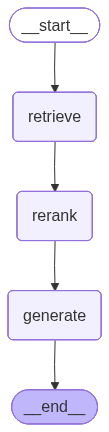

In [12]:
# 그래프 시각화
from IPython.display import Image

try:
    display(Image(rag_chain.get_graph().draw_mermaid_png()))
except Exception:
    print(rag_chain.get_graph().draw_mermaid())

## 6. RAG Chain 테스트

In [14]:
RAG_QUERIES = ['지분법 적용을 중지해야 하는 경우를 알려줘']

    # "유형자산 감가상각 방법을 설명해줘"
    # "금융자산의 기대신용손실은 어떻게 측정하나요?",
    # "사용권자산과 리스부채의 최초 측정 방법은?",

for q in RAG_QUERIES:
    print(f"\n{'=' * 70}")
    print(f"  질문: {q}")
    print('=' * 70)

    result = rag_chain.invoke({"query": q})

    # 검색된 context 요약
    print(f"\n  [검색 컨텍스트] {len(result['retrieved_docs'])}개 후보 → {len(result['context'])}개 선정")
    for i, doc in enumerate(result["context"], 1):
        m = doc.metadata
        score = m.get("rerank_score", "?")
        print(f"    {i}. {m.get('standard_id','?')} 문단 {m.get('para_number','?')} (score={score})")

    # 답변 출력
    print()
    display(Markdown(f"**답변:**\n\n{result['answer']}"))


  질문: 지분법 적용을 중지해야 하는 경우를 알려줘

  [검색 컨텍스트] 30개 후보 → 5개 선정
    1. K-IFRS 1028 문단 38 (score=0.886224)
    2. K-IFRS 1028 문단 21 (score=0.870267)
    3. K-IFRS 1028 문단 BC27 (score=0.756717)
    4. K-IFRS 1028 문단 23 (score=0.737158)
    5. K-IFRS 1112 문단 22 (score=0.710729)



**답변:**

# 지분법 적용 중지 사유

K-IFRS 1028에 따르면, 지분법 사용을 중단해야 하는 경우는 다음과 같습니다.

## 1. 투자가 관계기업이나 공동기업의 정의를 충족하지 못하는 경우

**기준서 제1028호 문단 21**에 따르면:
> "기업은 투자가 다음과 같이 관계기업이나 공동기업의 정의를 충족하지 못하게 된 시점부터 지분법의 사용을 중단한다"

구체적으로는:
- **피투자기업이 종속기업이 되는 경우**: 기업은 그 투자를 기업회계기준서 제1110호에 따라 회계처리합니다.

## 2. 매각예정 분류 기준 미충족

**기준서 제1028호 문단 21**에 따르면:
> "이전에 매각예정으로 분류된 관계기업이나 공동기업에 대한 투자 또는 그 투자의 일부가 더 이상 그 분류기준을 충족하지 않는다면 당초 매각예정으로 분류되었던 시점부터 소급하여 지분법으로 회계처리한다"

## 3. 지분법 중단 시 회계처리

지분법을 중단할 때는 **기준서 제1028호 문단 21, 23**에 따라:
- 잔여 보유 지분을 공정가치로 측정
- 기타포괄손익으로 인식한 금액을 당기손익으로 재분류

## 7. 커스텀 질문

원하는 질문을 입력하여 RAG 체인을 테스트합니다.

In [26]:
# 질문을 변경하여 실행해 보세요
custom_question = "기타포괄손익의 재분류조정에 대해 알려줘"

result = rag_chain.invoke({"query": custom_question})

print(f"질문: {custom_question}")
print(f"컨텍스트: {len(result['context'])}개 문서\n")
display(Markdown(result["answer"]))

질문: 기타포괄손익의 재분류조정에 대해 알려줘
컨텍스트: 5개 문서



# 기타포괄손익의 재분류조정에 대한 설명

## 1. 재분류조정의 정의

**기준서 제1001호 문단 93**에 따르면, 재분류조정은 **과거기간에 기타포괄손익으로 인식한 금액을 당기손익으로 재분류하는 것**을 의미합니다.

## 2. 재분류조정이 필요한 이유

**기준서 제1001호 결론도출근거 BC69**에 따르면:

- **이중계산 방지**: IFRS에 따라 항목이 당기손익으로 재분류될 때, 총포괄손익에 이중으로 기록되는 것을 피하기 위해 필수적입니다.

- **정보 제공**: 재무제표이용자가 다음을 평가할 수 있도록 정보를 제공합니다:
  - 당기손익에 미치는 재분류의 영향
  - 매도가능금융상품, 현금흐름위험회피, 해외사업장의 환산이나 처분과 관련된 전체적인 손익

## 3. 재분류조정의 표시 방법

**기준서 제1001호 문단 94**에 따르면:

- 재분류조정은 **포괄손익계산서나 주석에 표시**할 수 있습니다.
- 주석에 표시하는 경우, **관련 재분류조정을 반영한 후에 기타포괄손익의 항목을 표시**합니다.

## 4. 법인세 처리

**기준서 제1001호 문단 7**에 따르면, 재분류조정과 관련한 법인세비용 금액은 포괄손익계산서나 주석에 공시해야 합니다.

## 8. 정리

In [ ]:
client.close()
print("Qdrant 연결 종료")